In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, classification_report, confusion_matrix

# 1. Load Data
url = 'https://www.dropbox.com/scl/fi/89qym139ok12cddal1mjf/movie_data.csv?rlkey=0o3esvk0afi4cuubqcj2ywjch&st=r1bkcksx&dl=1'
df = pd.read_csv(url)
df.head()

,Movie_Title,Budget_M,Runtime_Min,Critic_Score,Rating,Success
0,Movie_0,107,108,49,6.160941,0
1,Movie_1,184,115,65,6.686535,1
2,Movie_2,97,92,25,5.036010,0
3,Movie_3,19,111,56,3.638897,0
4,Movie_4,111,150,43,3.957981,0


--- Movie is a Miss ---

--- Model Metrics ---
Accuracy Score: 100.00%
Mean Squared Error (MSE): 0.0000
R2 Score: 1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00         9

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



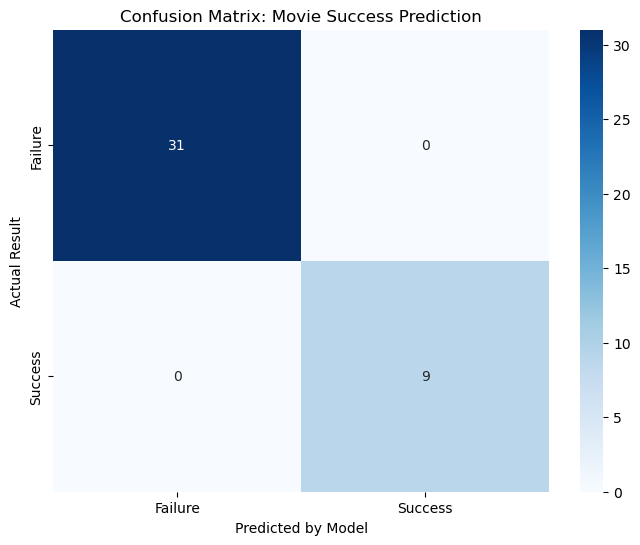

In [17]:
# 2. Preprocessing: Define Features (X) and Target (y)
X = df.drop(columns=['Movie_Title', 'Success'])
y = df['Success']

# 3. Split Data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. SCALING:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Model Training
model = SVC(C=10, gamma=0.1, kernel='rbf')
model.fit(X_train_scaled, y_train)

# 6. Predictions & Evaluation
y_pred = model.predict(X_test_scaled)
Test_Prediction = pd.DataFrame([[100, 200, 25, 5.686535]], columns=['Budget_M', 'Runtime_Min', 'Critic_Score', 'Rating'])
scaled_Test_data = scaler.transform(Test_Prediction)
Result = model.predict(scaled_Test_data)

if Result == 1:
    print("--- Movie is a Hit ---")
else:
    print("--- Movie is a Miss ---")
 
# Metrics
print("\n--- Model Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 7. Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Failure', 'Success'], yticklabels=['Failure', 'Success'])
plt.title('Confusion Matrix: Movie Success Prediction')
plt.xlabel('Predicted by Model')
plt.ylabel('Actual Result')
plt.show()